In [ ]:
!pip install tensorflow==2.19.0

In [ ]:
!pip install netron

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 63.3 MB/s eta 0:00:00


# ALL import line for image classsfictaion model workflow

In [1]:
from tensorflow.keras.models import Sequential
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Image,display
from tensorflow.keras.applications import VGG16
import tensorflow as tf
import matplotlib.pyplot as plt

In [15]:
from tensorflow.keras.layers import Flatten , Dense, Input, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [18]:
from tensorflow.keras.optimizers import Adam

# Downloading dataset from kaggel

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vencerlanz09/agricultural-pests-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 102M/102M [00:00<00:00, 146MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vencerlanz09/agricultural-pests-image-dataset/versions/1


# initialization of variables

In [3]:
ants=[]
bees=[]
beetle=[]
catterpillar=[]
earthworm=[]
earwig=[]
grasshopper=[]
moth=[]
slug=[]
snail=[]
wasp=[]
weevil=[]
IMG_SIZE=200


loading data to variables

In [4]:
for i in os.listdir(path):
  if i =='ants':
    for j in os.listdir(path+'/'+i):
      ants.append(path+'/'+i+'/'+j)
  if i =='bees':
    for j in os.listdir(path+'/'+i):
      bees.append(path+'/'+i+'/'+j)
  if i =='beetle':
    for j in os.listdir(path+'/'+i):
      beetle.append(path+'/'+i+'/'+j)
  if i =='catterpillar':
    for j in os.listdir(path+'/'+i):
      catterpillar.append(path+'/'+i+'/'+j)
  if i =='earthworms':
    for j in os.listdir(path+'/'+i):
      earthworm.append(path+'/'+i+'/'+j)
  if i =='earwig':
    for j in os.listdir(path+'/'+i):
      earwig.append(path+'/'+i+'/'+j)
  if i =='grasshopper':
    for j in os.listdir(path+'/'+i):
      grasshopper.append(path+'/'+i+'/'+j)
  if i =='moth':
    for j in os.listdir(path+'/'+i):
      moth.append(path+'/'+i+'/'+j)
  if i =='slug':
    for j in os.listdir(path+'/'+i):
      slug.append(path+'/'+i+'/'+j)
  if i =='snail':
    for j in os.listdir(path+'/'+i):
      snail.append(path+'/'+i+'/'+j)
  if i =='wasp':
    for j in os.listdir(path+'/'+i):
      wasp.append(path+'/'+i+'/'+j)
  if i =='weevil':
    for j in os.listdir(path+'/'+i):
      weevil.append(path+'/'+i+'/'+j)


In [5]:
data = {
    'ants': ants,
    'bees': bees,
    'beetle': beetle,
    'catterpillar': catterpillar,
    'earthworm': earthworm,
    'earwig': earwig,
    'grasshopper': grasshopper,
    'moth': moth,
    'slug': slug,
    'snail': snail,
    'wasp': wasp,
    'weevil': weevil
}
rows = []
for label, images in data.items():
    for img in images:
        rows.append({'image': img, 'label': label})

df = pd.DataFrame(rows)
print(len(df))

5494


# Encoding of Data

In [6]:
from tensorflow.keras.utils import to_categorical
df['label_encoded']=df['label'].astype('category').cat.codes
mapping = dict(zip(df['label_encoded'], df['label']))
print(mapping)

{0: 'ants', 1: 'bees', 2: 'beetle', 3: 'catterpillar', 4: 'earthworm', 5: 'earwig', 6: 'grasshopper', 7: 'moth', 8: 'slug', 9: 'snail', 10: 'wasp', 11: 'weevil'}


In [7]:
count=df['label'].value_counts()
print(f"Label\tcounts\n{count}")

Label	counts
label
bees            500
snail           500
ants            499
wasp            498
moth            497
grasshopper     485
weevil          485
earwig          466
catterpillar    434
beetle          416
slug            391
earthworm       323
Name: count, dtype: int64


Data is balanced so no issues

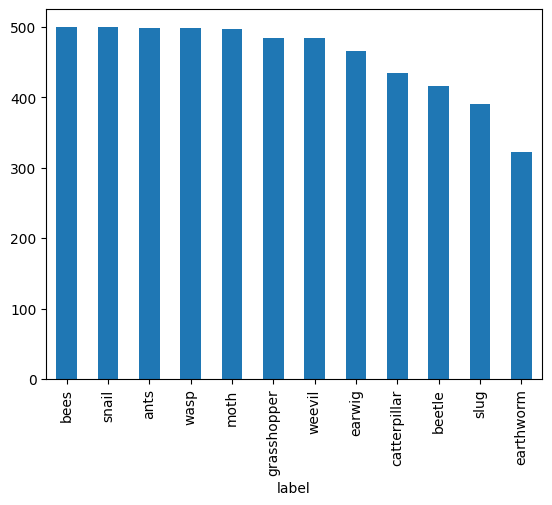

In [8]:
count.plot(kind='bar')
plt.show()

# Image loader

In [9]:
def load_image(path):
  img=cv2.imread(path)
  img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
  img=cv2.resize(img,(200,200))
  img=img/255.0
  img = np.expand_dims(img, axis=0)
  return img

Testing image loader and label

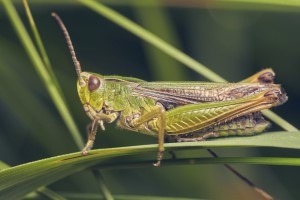

grasshopper


In [10]:
n=np.random.randint(0,len(df))
img=load_image(df['image'][n])
display(Image(filename=df['image'][n]))
print(df['label'][n])

# Splitting of Data for Train and Test

In [11]:
#splitting into train and test data frame
train_df,test_df=train_test_split(df,random_state=47,test_size=0.2)

**Data creator**

In [12]:
import tensorflow as tf

def create_data(df,batch_size=32):
  paths=df['image'].values
  label=df['label_encoded'].values

  def load(path,label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

  dataset = tf.data.Dataset.from_tensor_slices((paths, label))
  dataset = dataset.map(lambda p, l: load(p, l))
  dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
  return dataset

Final dataset for training

In [14]:
train_dataset=create_data(train_df)
test_dataset=create_data(test_df)

# Building Model

**VGG16** model from IMAGENET 4 trainable layers

In [16]:
vgg=VGG16(include_top=False,input_shape=(IMG_SIZE, IMG_SIZE,3))
vgg.trainable=False

for layer in vgg.layers[-4:]:
  layer.trainable=True


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Dense layers**

In [17]:
last=vgg.layers[-1].output

flat=GlobalAveragePooling2D()(last)

layer1=Dense(64,activation='relu')(flat)

layer2=Dense(128,activation='relu')(layer1)

layer3=Dense(256,activation='relu')(layer2)
layer3=Dropout(0.5)(layer3)

layer4=Dense(512,activation='relu')(layer3)
layer4=BatchNormalization()(layer4)
layer4=Dropout(0.5)(layer4)

output_layer=Dense(12,activation='softmax')(layer4)

model=Model(inputs=vgg.input,outputs=output_layer)


**Compiler**

In [19]:
model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

**Summary**

In [20]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,928,652 (56.95 MB)

 Trainable params: 7,292,364 (27.82 MB)

 Non-trainable params: 7,636,288 (29.13 MB)

# Training The Model

In [22]:
model.fit(train_dataset,
          validation_data=test_dataset,
          epochs=10,
          callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
              tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)]
          )
model.save('Argiculture_Model_v3.keras')

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.7235 - loss: 0.7165 - val_accuracy: 0.5878 - val_loss: 1.3102 - learning_rate: 5.0000e-04
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 244ms/step - accuracy: 0.7629 - loss: 0.6196 - val_accuracy: 0.5560 - val_loss: 1.4553 - learning_rate: 5.0000e-04
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 36s 264ms/step - accuracy: 0.7757 - loss: 0.5584 - val_accuracy: 0.5987 - val_loss: 1.3014 - learning_rate: 5.0000e-04
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 248ms/step - accuracy: 0.8082 - loss: 0.4957 - val_accuracy: 0.5787 - val_loss: 1.5323 - learning_rate: 5.0000e-04
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.8353 - loss: 0.4259 - val_accuracy: 0.6342 - val_loss: 1.2690 - learning_rate: 5.0000e-04
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 33s 241ms/step - accuracy: 0.8573 - loss: 0.3732 - val_accuracy: 0.6078 - val_loss: 1.4397 - learning_rate: 5.0000e-04
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 34s 24

# **Testing**

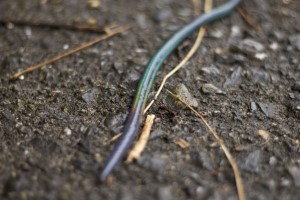

Actual:earthworm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted:earthworm


In [44]:
from IPython.display import Image, display
from numpy import random
n=np.random.randint(0,len(test_df))
img=load_image(test_df.iloc[n,0])
display(Image(filename=test_df.iloc[n,0]))
print(f"Actual:{test_df.iloc[n,1]}")
y=model.predict(img)
predicted=mapping[np.argmax(y)]
print(f"Predicted:{predicted}")